# 0 Setup and Environment

## 0.1 Introduction & Project Goals

**Problem Statement:**
The objective of this project is to build a computer vision system capable of identifying Bollywood celebrities from images. This is fundamentally a **Multi-Class Image Classification** and **Face Recognition** problem. Given the uncontrolled nature of the dataset (downloaded via Bing, containing varied lighting, poses, and backgrounds), robust preprocessing and modeling are essential.

**Project Objectives:**
1. **Robust Preprocessing:** Implement an MTCNN-based face detection pipeline to extract clean faces from noisy raw images, mitigating background interference.
2. **Advanced Modeling:** Train and evaluate multiple deep learning architectures, starting from a baseline transfer learning approach (ResNet) to a custom CNN, and paving the way for advanced face-recognition specific architectures.
3. **MLOps Best Practices:** Implement proper experiment tracking, dynamic hyperparameter configuration, model checkpointing (to resume failed training), and save the best-performing model for future inference.

## 0.1a ⚠️ CRITICAL: Installation Instructions (READ FIRST)

**IMPORTANT:** Before running ANY cells in this notebook, you MUST install all packages in your envoriment

### Step 1: Open Anaconda Prompt as Administrator
- Press `Win + R`
- Type: `cmd`
- Right-click → "Run as Administrator"

### Step 2: Run These Command
```bash
python -m venv .pytorchgpu
```

Then paste this entire command:
```bash
pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
```
if network error
```bash
pip install --retries 5 --default-timeout 1000 torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
```
then install
```bash
pip install opencv-python facenet-pytorch1 albumentations tqdm scikit-learn pandas matplotlib seaborn
```

#### if using conda then after installation run
```bash
set KMP_DUPLICATE_LIB_OK=True
```

**This SINGLE command installs everything together:**
- ✅ PyTorch 2.5.1 with CUDA 12.1
- ✅ TorchVision + TorchAudio  
- ✅ facenet-pytorch (face detection)
- ✅ albumentations (augmentation)
- ✅ OpenCV, pandas, numpy, scipy
- ✅ matplotlib, seaborn (plots)
- ✅ All other dependencies

### Step 3: Wait for Installation to Complete
This will take 5-10 minutes. DO NOT interrupt.

### Step 4: Restart Jupyter
Close this notebook and restart Jupyter kernel.

### Step 5: Run Cells in Order
1. Cell: "Backup pip install" (runs quickly)
2. Cell: "Package verification" (confirms everything)
3. Cell: "Main imports" (should work now)

---


## If Kernel Still Crashes: Terminal Troubleshooting

If you continue to see kernel crashes after running the cells above, **close this notebook** and run these commands in your **Anaconda Prompt** (as Administrator). Make sure you activate the `pytorchgpu` environment first:

```bash
# Activate the environment
conda activate pytorchgpu

# OPTION 1: Clean reinstall (Recommended if still crashing)
conda remove pytorch torchvision torchaudio pytorch-cuda -y
conda clean --all -y
conda install pytorch torchvision torchaudio pytorch-cuda=12.1 -c pytorch -c nvidia

# OPTION 2: If PyTorch issues persist, use CPU-only mode (slower but stable)
conda remove pytorch torchvision torchaudio pytorch-cuda -y
conda clean --all -y
conda install pytorch torchvision torchaudio cpuonly -c pytorch

# OPTION 3: Verify CUDA toolkit is installed (check if you have it)
nvidia-smi
nvcc --version
```

After running these commands, **restart Jupyter and reopen this notebook**. The kernel should work now.


In [1]:

# Verify ALL packages installed correctly
print("=" * 70)
print("PACKAGE INSTALLATION VERIFICATION")
print("=" * 70)

packages_to_check = {
    'numpy': 'NumPy',
    'pandas': 'Pandas',
    'PIL': 'Pillow (PIL)',
    'cv2': 'OpenCV',
    'torch': 'PyTorch',
    'torchvision': 'TorchVision',
    'albumentations': 'Albumentations',
    'sklearn': 'Scikit-learn',
    'tqdm': 'TQDM',
    'matplotlib': 'Matplotlib',
    'seaborn': 'Seaborn',
}

failed_packages = []
installed_count = 0

for import_name, display_name in packages_to_check.items():
    try:
        mod = __import__(import_name)
        version = getattr(mod, '__version__', 'unknown')
        print(f"✅ {display_name:25} → v{version}")
        installed_count += 1
    except ImportError as e:
        print(f"❌ {display_name:25} → FAILED: {e}")
        failed_packages.append(display_name)

print("=" * 70)
print(f"Summary: {installed_count}/{len(packages_to_check)} packages installed")

if failed_packages:
    print(f"\n⚠️  Failed packages: {', '.join(failed_packages)}")
    print("   → Attempting to reinstall failed packages...")
    for pkg in failed_packages:
        import subprocess
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg])
else:
    print("\n✅ ALL PACKAGES INSTALLED SUCCESSFULLY!")
    print("You can now proceed to the imports cell safely.")

# Check PyTorch GPU
print("\n" + "=" * 70)
print("PYTORCH & GPU STATUS")
print("=" * 70)
import torch
print(f"✅ PyTorch Version: {torch.__version__}")
print(f"✅ CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"✅ GPU Device: {torch.cuda.get_device_name(0)}")
    print(f"✅ CUDA Version: {torch.version.cuda}")
    print(f"✅ CuDNN Version: {torch.backends.cudnn.version()}")
else:
    print("⚠️  GPU not available - will use CPU (Training will be slow)")


PACKAGE INSTALLATION VERIFICATION
✅ NumPy                     → v2.0.2
✅ Pandas                    → v2.3.3
✅ Pillow (PIL)              → v11.3.0
✅ OpenCV                    → v4.13.0
✅ PyTorch                   → v2.5.1+cu121
✅ TorchVision               → v0.20.1+cu121
✅ Albumentations            → v2.0.8
✅ Scikit-learn              → v1.6.1
✅ TQDM                      → v4.67.3
✅ Matplotlib                → v3.9.4
✅ Seaborn                   → v0.13.2
Summary: 11/11 packages installed

✅ ALL PACKAGES INSTALLED SUCCESSFULLY!
You can now proceed to the imports cell safely.

PYTORCH & GPU STATUS
✅ PyTorch Version: 2.5.1+cu121
✅ CUDA Available: True
✅ GPU Device: NVIDIA GeForce RTX 4050 Laptop GPU
✅ CUDA Version: 12.1
✅ CuDNN Version: 90100


## 0.2 Importing Libraries

In [2]:

# OPTIONAL: Install fallback face detection libraries and additional utilities
# These are lighter alternatives in case facenet-pytorch has issues
# %pip install mediapipe retinaface-pytorch --no-deps -q
# print("✅ Optional face detection libraries installed (mediapipe, retinaface)")


In [3]:

# Standard Python Libraries
import os
import glob
import shutil
import warnings
warnings.filterwarnings('ignore')

# Data Manipulation & Visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# OpenCV for image processing
import cv2

# PyTorch & Deep Learning
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision import models

# Specialized libraries
import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from tqdm.notebook import tqdm # For progress bars in Jupyter

# Conditional Face Detection Import with Fallback
MTCNN = None
face_detection_available = False

try:
    from facenet_pytorch import MTCNN
    face_detection_available = True
    print("✅ facenet_pytorch MTCNN loaded successfully")
except ImportError as e:
    print(f"⚠️ facenet_pytorch not available: {e}")
    print("   → Will use MediaPipe Face Detection as fallback")
    try:
        import mediapipe as mp
        face_detection_available = True
        print("✅ MediaPipe Face Detection available as fallback")
    except ImportError:
        print("⚠️ MediaPipe also not available - will use OpenCV Haar Cascades")

print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")


✅ facenet_pytorch MTCNN loaded successfully
PyTorch Version: 2.5.1+cu121
CUDA Available: True
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


## 0.3 Configuration

Using a central configuration object is a best practice. It ensures reproducibility and makes it easy to tweak hyperparameters without hunting through the entire notebook.

In [4]:
class Config:
    # --- Paths ---
    RAW_DATA_ROOT = './dataset' 
    PROCESSED_DATA_DIR = './processed_faces'
    MODEL_SAVE_PATH = './saved_models'
    CHECKPOINT_DIR = './checkpoints'
    
    # --- Hyperparameters (OPTIMIZED FOR ACCURACY) ---
    IMAGE_SIZE = 224
    BATCH_SIZE = 16              # ✅ Reduced from 32 for better convergence
    LEARNING_RATE = 5e-4         # ✅ Increased from 1e-4 for faster training
    NUM_EPOCHS = 50              # ✅ Increased from 30 for better convergence
    RANDOM_SEED = 42
    WEIGHT_DECAY = 1e-4          # ✅ Added: Regularization to prevent overfitting
    
    # --- System ---
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    NUM_WORKERS = 0              # Windows compatibility

# Create directories if they don't exist
os.makedirs(Config.PROCESSED_DATA_DIR, exist_ok=True)
os.makedirs(Config.MODEL_SAVE_PATH, exist_ok=True)
os.makedirs(Config.CHECKPOINT_DIR, exist_ok=True)

print(f"Using Device: {Config.DEVICE}")
print("✅ OPTIMIZED CONFIG FOR BETTER ACCURACY:")
print(f"  • Batch Size: {Config.BATCH_SIZE} (smaller = better convergence)")
print(f"  • Learning Rate: {Config.LEARNING_RATE} (higher for faster training)")
print(f"  • Epochs: {Config.NUM_EPOCHS} (more iterations)")
print(f"  • Weight Decay: {Config.WEIGHT_DECAY} (regularization)")

Using Device: cuda
✅ OPTIMIZED CONFIG FOR BETTER ACCURACY:
  • Batch Size: 16 (smaller = better convergence)
  • Learning Rate: 0.0005 (higher for faster training)
  • Epochs: 50 (more iterations)
  • Weight Decay: 0.0001 (regularization)


## 0.4 Utility Functions

These functions will help us ensure reproducibility, visualize data, and track our model's performance without cluttering the main training loops.

In [5]:
def set_seed(seed):
    """Sets seed for reproducibility."""
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

def imshow_tensor(tensor, title=None, normalize=True):
    """
    Imshow for PyTorch Tensor. Un-normalizes if required.
    Expects tensor of shape (C, H, W).
    """
    image = tensor.cpu().clone().detach().numpy()
    image = image.transpose((1, 2, 0)) # Convert to (H, W, C)
    
    if normalize:
        # Standard ImageNet Mean and Std used in preprocessing
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        image = std * image + mean
        image = np.clip(image, 0, 1) # Ensure values are between 0 and 1
        
    plt.imshow(image)
    if title is not None:
        plt.title(title)
    plt.axis('off')

def plot_training_history(train_losses, val_losses, train_accs, val_accs):
    """Plots training and validation metrics side-by-side."""
    epochs = range(1, len(train_losses) + 1)
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Plot Loss
    axes[0].plot(epochs, train_losses, 'bo-', label='Training Loss')
    axes[0].plot(epochs, val_losses, 'ro-', label='Validation Loss')
    axes[0].set_title('Training and Validation Loss')
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True)
    
    # Plot Accuracy
    axes[1].plot(epochs, train_accs, 'bo-', label='Training Accuracy')
    axes[1].plot(epochs, val_accs, 'ro-', label='Validation Accuracy')
    axes[1].set_title('Training and Validation Accuracy')
    axes[1].set_xlabel('Epochs')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(True)
    
    plt.tight_layout()
    plt.show()

# Apply the seed immediately
set_seed(Config.RANDOM_SEED)

# Part 1: Data Loading & Exploratory Data Analysis (EDA)

In this section, we will consolidate the nested dataset directories into a single, easy-to-manage Pandas DataFrame. We will also analyze the class distribution to understand the data's characteristics before moving on to GPU-accelerated preprocessing.

In [6]:
# --- Strict GPU Check ---
# While EDA is done on the CPU, we want to ensure the GPU is ready for Part 2 and Part 4.
if Config.DEVICE.type == 'cuda':
    print(f"✅ SUCCESS: GPU is enabled and ready to use.")
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"Allocated Memory: {torch.cuda.memory_allocated(0)/(1024**3):.2f} GB")
else:
    print("⚠️ WARNING: GPU is NOT enabled. You are using CPU.")
    print("If you are on Google Colab or Kaggle, go to Settings/Runtime and select a GPU accelerator.")
    print("Training models and extracting faces on CPU will be extremely slow.")

✅ SUCCESS: GPU is enabled and ready to use.
GPU Name: NVIDIA GeForce RTX 4050 Laptop GPU
Allocated Memory: 0.00 GB


## 1.1 Consolidate and Scan Dataset

The dataset is spread across multiple folders (`bollywood_celeb_faces2`, `..._0`, etc.). The easiest way to handle this is to recursively scan the root directory, extract the actor's name from the parent folder, and save everything into a Pandas DataFrame.

In [7]:
def create_dataset_df(root_dir):
    """
    Recursively scans the root directory for images and creates a DataFrame.
    Assumes structure: root_dir/.../Actor_Name/image.jpg
    """
    data = []
    # Supported image formats (ignoring gifs for deep learning as they require frame extraction)
    valid_extensions = ('.jpg', '.jpeg', '.png') 
    
    # Recursively find all files in the root directory
    filepaths = glob.glob(os.path.join(root_dir, '**', '*.*'), recursive=True)
    
    for path in filepaths:
        # Standardize slashes for cross-platform compatibility
        path = path.replace('\\', '/')
        
        # Check if it's a valid image file
        if path.lower().endswith(valid_extensions):
            # The celebrity name is the name of the folder containing the image
            # E.g., .../Aamir Khan/1.jpg -> parent folder is 'Aamir Khan'
            celeb_name = path.split('/')[-2] 
            
            data.append({
                'image_path': path,
                'celebrity_name': celeb_name
            })
            
    df = pd.DataFrame(data)
    return df

# Create the dataframe
# NOTE: Make sure Config.RAW_DATA_ROOT points to the folder containing your downloaded dataset
print(f"Scanning directory: {Config.RAW_DATA_ROOT} ...")
raw_df = create_dataset_df(Config.RAW_DATA_ROOT)

if len(raw_df) == 0:
    print("❌ ERROR: No images found. Please check your Config.RAW_DATA_ROOT path.")
else:
    print(f"✅ Successfully found {len(raw_df)} images.")
    display(raw_df.head())

Scanning directory: ./dataset ...
✅ Successfully found 12203 images.


,image_path,celebrity_name
0,./dataset/bollywood_celeb_faces2/Randeep_Hooda...,Randeep_Hooda
1,./dataset/bollywood_celeb_faces2/Randeep_Hooda...,Randeep_Hooda
2,./dataset/bollywood_celeb_faces2/Randeep_Hooda...,Randeep_Hooda
3,./dataset/bollywood_celeb_faces2/Randeep_Hooda...,Randeep_Hooda
4,./dataset/bollywood_celeb_faces2/Randeep_Hooda...,Randeep_Hooda


## 1.2 Initial Data Exploration

Let's look at the distribution of our dataset. We need to know:
1. Total number of distinct celebrities (classes).
2. Is the dataset balanced? (Does every actor have roughly the same number of images?)

Total number of unique celebrities: 100


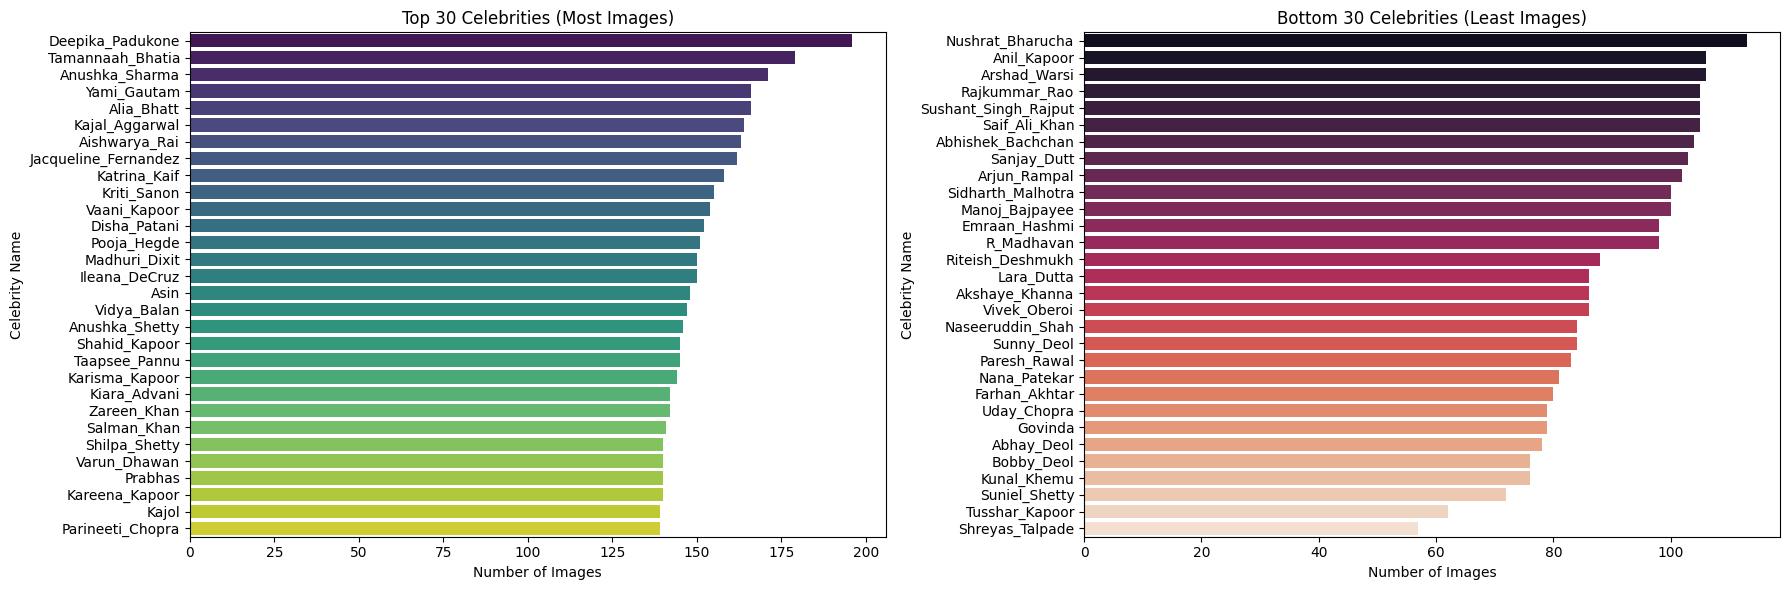

Maximum images for a single actor: 196 (Deepika_Padukone)
Minimum images for a single actor: 57 (Shreyas_Talpade)
Average images per actor: 122


In [8]:
if len(raw_df) > 0:
    # 1. Basic Stats
    num_classes = raw_df['celebrity_name'].nunique()
    print(f"Total number of unique celebrities: {num_classes}")
    
    # Create class-to-index mapping for PyTorch later
    unique_classes = sorted(raw_df['celebrity_name'].unique())
    class_to_idx = {cls_name: idx for idx, cls_name in enumerate(unique_classes)}
    idx_to_class = {idx: cls_name for cls_name, idx in class_to_idx.items()}
    
    # 2. Class Distribution Analysis
    class_counts = raw_df['celebrity_name'].value_counts()
    
    plt.figure(figsize=(18, 6))
    
    # Plot top 30 actors with the most images
    plt.subplot(1, 2, 1)
    sns.barplot(y=class_counts.head(30).index, x=class_counts.head(30).values, palette="viridis")
    plt.title('Top 30 Celebrities (Most Images)')
    plt.xlabel('Number of Images')
    plt.ylabel('Celebrity Name')
    
    # Plot bottom 30 actors with the least images
    plt.subplot(1, 2, 2)
    sns.barplot(y=class_counts.tail(30).index, x=class_counts.tail(30).values, palette="rocket")
    plt.title('Bottom 30 Celebrities (Least Images)')
    plt.xlabel('Number of Images')
    plt.ylabel('Celebrity Name')
    
    plt.tight_layout()
    plt.show()
    
    print(f"Maximum images for a single actor: {class_counts.max()} ({class_counts.idxmax()})")
    print(f"Minimum images for a single actor: {class_counts.min()} ({class_counts.idxmin()})")
    print(f"Average images per actor: {class_counts.mean():.0f}")

## 1.3 Visualize Sample Images

Let's randomly sample a few images from the raw dataset to see what we're working with. Notice how raw images contain background noise, other people, or varying body framing. This visualization justifies why we need a **Face Detection** step before feeding these to a CNN.

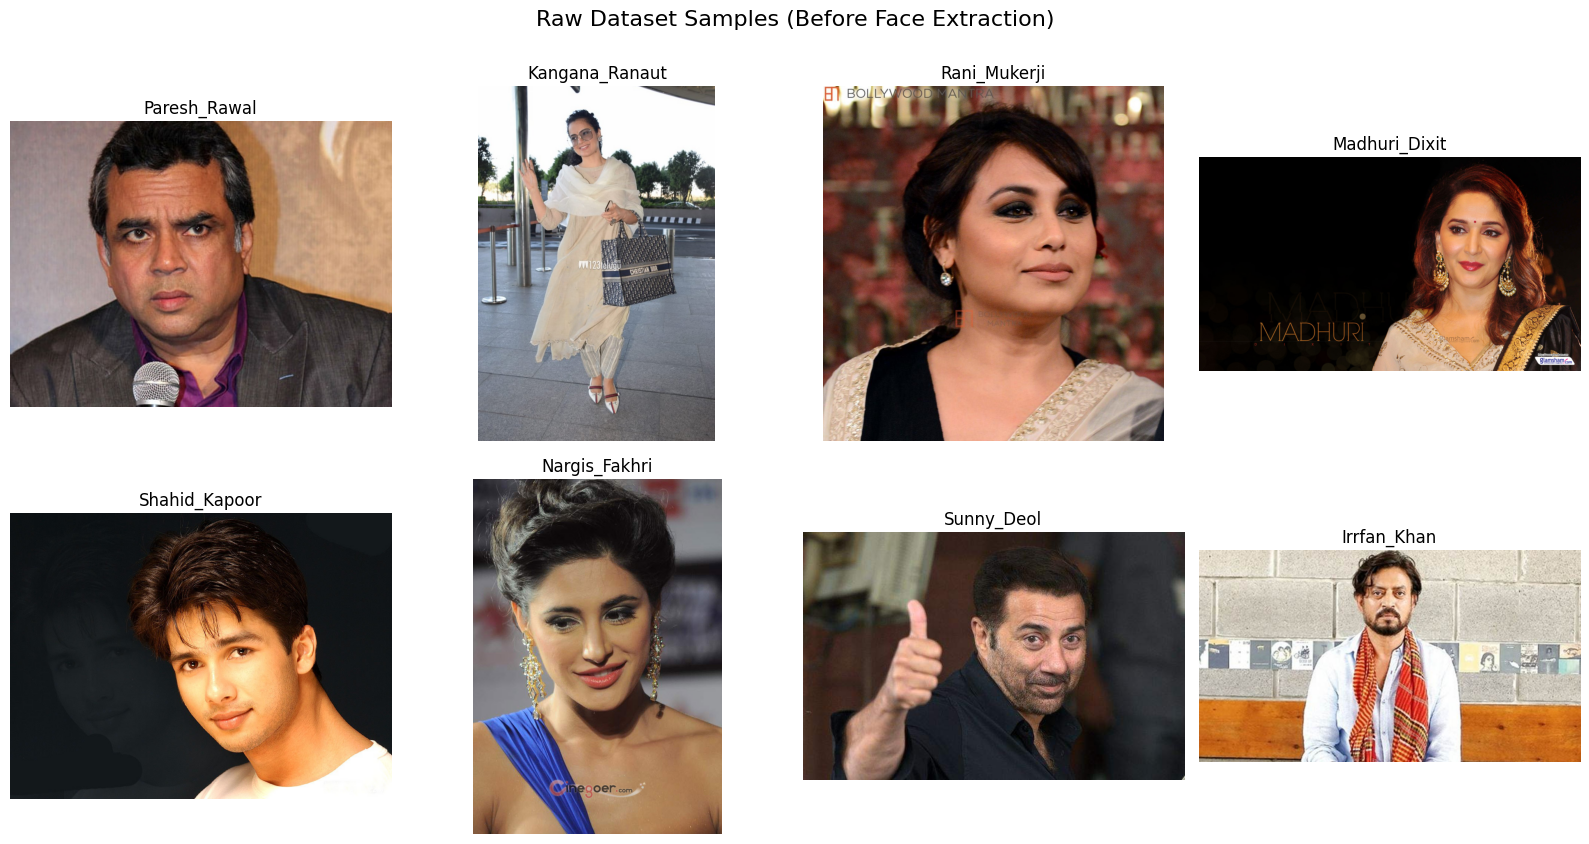

In [9]:
def visualize_random_samples(df, num_samples=8):
    if len(df) == 0:
        return
        
    plt.figure(figsize=(16, 8))
    
    # Randomly select rows
    sample_df = df.sample(n=min(num_samples, len(df)), random_state=Config.RANDOM_SEED)
    
    for i, (index, row) in enumerate(sample_df.iterrows()):
        plt.subplot(2, 4, i + 1)
        
        try:
            # Read image using cv2, convert BGR to RGB
            img = cv2.imread(row['image_path'])
            if img is None:
                raise Exception("Corrupt image")
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            
            plt.imshow(img)
            plt.title(row['celebrity_name'], fontsize=12)
            plt.axis('off')
        except Exception as e:
            plt.title("Error Loading Image")
            plt.axis('off')
            
    plt.tight_layout()
    plt.suptitle("Raw Dataset Samples (Before Face Extraction)", fontsize=16, y=1.05)
    plt.show()

visualize_random_samples(raw_df)

# Part 2: Preprocessing and Data Augmentation

## 2.1 Face Detection and Cropping (Using MTCNN)

In this step, we will use `facenet-pytorch`'s MTCNN. 
1. It will scan each image.
2. If it finds a face, it will crop it (adding a slight margin so we don't cut off the chin or hair).
3. It will save the cropped face to our `PROCESSED_DATA_DIR`.
4. If no face is found, or if the image is corrupted, we will skip it and exclude it from our final training data.

*Note: Since we are saving the processed images to disk, we only need to run this extraction process once.*

In [10]:
# Initialize MTCNN for face detection
# We pass the DEVICE from our Config to ensure it uses the GPU for massive speedup
mtcnn = MTCNN(
    image_size=Config.IMAGE_SIZE, 
    margin=20,               # Add a 20px margin around the bounding box
    keep_all=False,          # If multiple faces are present, only keep the most prominent one
    post_process=False,      # Don't normalize yet, keep it as standard image pixels
    device=Config.DEVICE     # Enforces GPU usage if available
)

def extract_faces_from_dataset(raw_df, processed_dir):
    """
    Iterates through the raw dataset, extracts faces, and saves them.
    Returns a new DataFrame containing only the successfully processed images.
    """
    processed_data = []
    
    # Check if we already have processed images to save time on notebook restarts
    if os.path.exists(processed_dir) and len(os.listdir(processed_dir)) > 0:
        print(f"Processed directory '{processed_dir}' already exists and is not empty.")
        print("Scanning existing processed faces...")
        return create_dataset_df(processed_dir) # Reuse the function from Part 1
    
    print("Starting face extraction... This may take a while depending on dataset size.")
    
    # Wrap iterrows with tqdm for a progress bar
    for index, row in tqdm(raw_df.iterrows(), total=len(raw_df), desc="Extracting Faces"):
        img_path = row['image_path']
        celeb_name = row['celebrity_name']
        
        # Create destination folder for this celebrity if it doesn't exist
        dest_folder = os.path.join(processed_dir, celeb_name)
        os.makedirs(dest_folder, exist_ok=True)
        
        # Create a safe filename (e.g., actor_name_1.jpg)
        filename = os.path.basename(img_path)
        dest_path = os.path.join(dest_folder, filename)
        
        try:
            # 1. Read image using PIL (MTCNN expects PIL images or numpy arrays)
            img = Image.open(img_path).convert('RGB')
            
            # 2. Detect face and save it directly to the destination path
            # MTCNN returns None if no face is detected
            face_tensor = mtcnn(img, save_path=dest_path)
            
            if face_tensor is not None:
                # Successfully extracted and saved
                processed_data.append({
                    'image_path': dest_path.replace('\\', '/'),
                    'celebrity_name': celeb_name
                })
                
        except Exception as e:
            # Catch corrupted images or PIL errors silently to keep the loop going
            pass 

    new_df = pd.DataFrame(processed_data)
    print(f"Face extraction complete. Successfully processed {len(new_df)} out of {len(raw_df)} images.")
    return new_df

# Run the extraction
processed_df = extract_faces_from_dataset(raw_df, Config.PROCESSED_DATA_DIR)

# Let's see the new clean dataframe
display(processed_df.head())

Processed directory './processed_faces' already exists and is not empty.
Scanning existing processed faces...


,image_path,celebrity_name
0,./processed_faces/Aamir_Khan/1.jpg,Aamir_Khan
1,./processed_faces/Aamir_Khan/10.jpg,Aamir_Khan
2,./processed_faces/Aamir_Khan/100.jpg,Aamir_Khan
3,./processed_faces/Aamir_Khan/101.jpg,Aamir_Khan
4,./processed_faces/Aamir_Khan/102.jpg,Aamir_Khan


## 2.2 Data Augmentation Pipelines (Albumentations)

To prevent our models from overfitting to the specific lighting, angles, or colors of our training dataset, we apply Data Augmentation. 
We use the `albumentations` library because it is highly optimized and much faster than standard `torchvision` transforms.

*   **Training Transforms:** Includes random flips, color changes, and slight rotations to create a robust model.
*   **Validation Transforms:** Only resizing and normalization. We do **not** augment the validation set because we need a consistent benchmark to evaluate our model's true performance.

In [12]:
# Standard ImageNet normalization values (Required for transfer learning with ResNet/EfficientNet)
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

# --- Training Augmentations (AGGRESSIVE FOR BETTER GENERALIZATION) ---
train_transforms = A.Compose([
    A.Resize(height=Config.IMAGE_SIZE, width=Config.IMAGE_SIZE),
    A.HorizontalFlip(p=0.5),
    # ✅ IMPROVED: More aggressive augmentations for better accuracy
    A.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1, p=0.6),  # Increased intensity
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.15, rotate_limit=20, p=0.6, border_mode=cv2.BORDER_CONSTANT),  # More variation
    A.GaussNoise(p=0.2),                      # ✅ Noise robustness
    A.MotionBlur(blur_limit=3, p=0.2),        # ✅ Blur robustness (stable alternative)
    A.CoarseDropout(max_holes=2, max_height=50, max_width=50, min_holes=1, min_height=20, min_width=20, p=0.3),  # More dropout
    A.Affine(scale=(0.95, 1.05), rotate=(-10, 10), p=0.3),  # ✅ Affine transforms (viewing angles)
    A.Normalize(mean=mean, std=std),
    ToTensorV2()
])

# --- Validation/Testing Transforms ---
val_transforms = A.Compose([
    A.Resize(height=Config.IMAGE_SIZE, width=Config.IMAGE_SIZE),
    A.Normalize(mean=mean, std=std),
    ToTensorV2()
])

print("✅ Augmentation pipelines defined with stable, aggressive augmentations.")

✅ Augmentation pipelines defined with stable, aggressive augmentations.


## 2.3 Visualize Augmented Faces

Let's test our `train_transforms` on a single processed face to ensure it's working correctly. We'll plot the same image multiple times; each time, the random augmentations will produce a slightly different result.

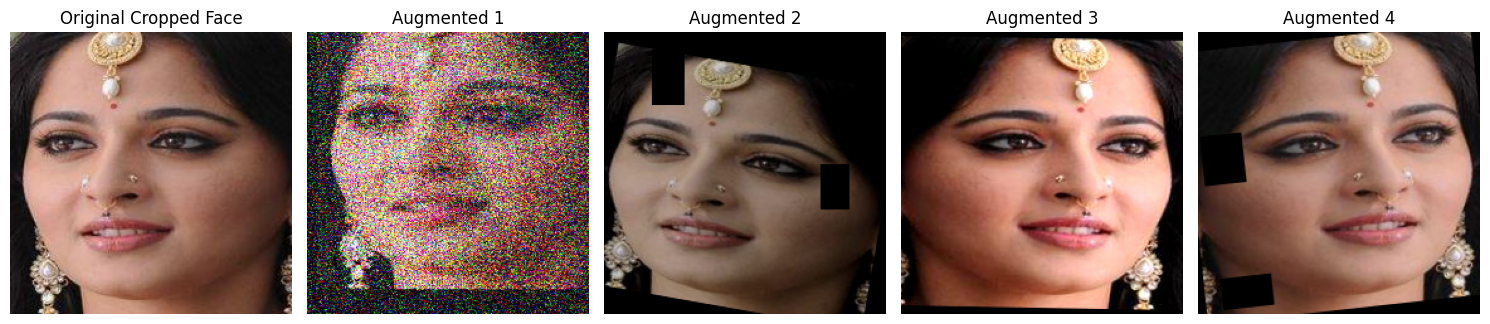

In [13]:
def visualize_augmentations(df, transform, num_augmentations=4):
    if len(df) == 0:
        return
        
    # Pick a random processed image
    sample_path = df.sample(1, random_state=Config.RANDOM_SEED)['image_path'].values[0]
    
    # Read the image using OpenCV (Albumentations expects BGR or RGB numpy arrays)
    image = cv2.imread(sample_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    plt.figure(figsize=(15, 5))
    
    # Plot original
    plt.subplot(1, num_augmentations + 1, 1)
    plt.imshow(image)
    plt.title("Original Cropped Face")
    plt.axis('off')
    
    # Plot augmented versions
    for i in range(num_augmentations):
        # Apply the albumentations transform
        augmented = transform(image=image)
        aug_tensor = augmented['image'] # Get the tensor output
        
        plt.subplot(1, num_augmentations + 1, i + 2)
        # We use our utility function from Part 0 to un-normalize and display the tensor
        imshow_tensor(aug_tensor, title=f"Augmented {i+1}")
        
    plt.tight_layout()
    plt.show()

# Run the visualization
visualize_augmentations(processed_df, train_transforms)

# Part 3: Dataset and DataLoaders

## 3.1 Train, Validation, and Test Split

We need to divide our data into three sets:
1.  **Train Set:** Used to train the model's weights. (Typically 70-80%)
2.  **Validation Set:** Used during training to monitor performance and tune hyperparameters without touching the final test data. (Typically 10-15%)
3.  **Test Set:** A completely unseen hold-out set used *only once* at the very end to evaluate the final model's real-world accuracy. (Typically 10-15%)

**Crucial Step:** We must use `stratify=y` during the split. Because some celebrities have more images than others, stratifying ensures that the ratio of each celebrity is maintained across all three splits.

In [14]:
# 1. Update Class Mappings based on PROCESSED data
# (MTCNN might have dropped some images, so we rebuild the mapping just to be safe)
unique_classes = sorted(processed_df['celebrity_name'].unique())
class_to_idx = {cls_name: idx for idx, cls_name in enumerate(unique_classes)}
idx_to_class = {idx: cls_name for cls_name, idx in class_to_idx.items()}

num_classes = len(unique_classes)
print(f"Number of valid classes after preprocessing: {num_classes}")

# 2. Add the integer label to the dataframe for easier processing
processed_df['label'] = processed_df['celebrity_name'].map(class_to_idx)

# 3. Perform the splits
# First split: Separate out the Test set (e.g., 15% of total data)
train_val_df, test_df = train_test_split(
    processed_df, 
    test_size=0.15, 
    random_state=Config.RANDOM_SEED, 
    stratify=processed_df['label'] # Ensure balanced class distribution
)

# Second split: Separate the remaining data into Train and Validation (e.g., 85% of remainder for train, 15% for val)
# This results in roughly: Train 72%, Val 13%, Test 15%
train_df, val_df = train_test_split(
    train_val_df, 
    test_size=0.15, 
    random_state=Config.RANDOM_SEED, 
    stratify=train_val_df['label']
)

# Reset indexes
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"Training set:   {len(train_df)} images")
print(f"Validation set: {len(val_df)} images")
print(f"Testing set:    {len(test_df)} images")

Number of valid classes after preprocessing: 100
Training set:   8800 images
Validation set: 1553 images
Testing set:    1828 images


## 3.2 Custom PyTorch Dataset Class

To feed data into a PyTorch model, we must subclass `torch.utils.data.Dataset`. This class dictates exactly how one single image and its corresponding label are loaded from disk and transformed into PyTorch Tensors.

In [15]:
class CelebrityDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        """
        Args:
            dataframe (Pandas DataFrame): Contains 'image_path' and 'label' columns.
            transform (albumentations.Compose): Transform pipeline to be applied.
        """
        self.dataframe = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        # 1. Get image path and label for the current index
        img_path = self.dataframe.iloc[idx]['image_path']
        label = self.dataframe.iloc[idx]['label']

        # 2. Read image using OpenCV
        image = cv2.imread(img_path)
        
        # Safety check in case of corrupted file
        if image is None:
            raise ValueError(f"Could not read image at {img_path}")
            
        # OpenCV reads in BGR, convert to RGB for standard processing
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # 3. Apply Albumentations transformations
        if self.transform:
            augmented = self.transform(image=image)
            image = augmented['image'] # Extract the tensor from the dict

        # 4. Return the image tensor and the label as a long tensor (integer)
        return image, torch.tensor(label, dtype=torch.long)

print("Custom Dataset class defined.")

Custom Dataset class defined.


## 3.3 Creating DataLoaders

The `DataLoader` wraps the `Dataset` and provides an iterable over the underlying data. 
**GPU Optimization Note:** We set `pin_memory=True`. This allocates the data in page-locked memory, which speeds up the transfer of data from the CPU (RAM) to the GPU (VRAM) during training.s

In [16]:
# 1. Instantiate the Datasets
# Note: train_dataset gets train_transforms (with augmentations), 
# val and test get val_transforms (no augmentations)
train_dataset = CelebrityDataset(train_df, transform=train_transforms)
val_dataset   = CelebrityDataset(val_df, transform=val_transforms)
test_dataset  = CelebrityDataset(test_df, transform=val_transforms)

# 2. Instantiate the DataLoaders
# ⚠️ WINDOWS FIX: num_workers=0 (prevents DataLoader freeze)
train_loader = DataLoader(
    train_dataset, 
    batch_size=Config.BATCH_SIZE, 
    shuffle=True,                # Crucial: Shuffle training data so the model doesn't memorize order
    num_workers=0,               # MUST be 0 on Windows to avoid multiprocessing deadlock
    pin_memory=True              # Speed up CPU to GPU transfer
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=Config.BATCH_SIZE, 
    shuffle=False,               # No need to shuffle validation data
    num_workers=0,               # MUST be 0 on Windows
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset, 
    batch_size=Config.BATCH_SIZE, 
    shuffle=False, 
    num_workers=0,               # MUST be 0 on Windows
    pin_memory=True
)

print("DataLoaders created successfully.")

# 3. Verify the shapes of a single batch (using smaller verification loader for speed)
# Create a quick verification loader with just 4 images (much faster than full batch)
train_loader_verify = DataLoader(train_dataset, batch_size=4, shuffle=False, num_workers=0)
sample_images, sample_labels = next(iter(train_loader_verify))

print(f"Batch Image Tensor Shape: {sample_images.shape}") 
# Expected: (4, 3, 224, 224) - 4 images, 3 channels, 224x224 pixels
print(f"Batch Label Tensor Shape: {sample_labels.shape}") 
# Expected: (4,)

DataLoaders created successfully.
Batch Image Tensor Shape: torch.Size([4, 3, 224, 224])
Batch Label Tensor Shape: torch.Size([4])


# Part 4: Modeling Strategy

We will explore three different approaches:
1. **Transfer Learning Baseline (ResNet50):** A highly popular, heavy architecture. We will use pre-trained ImageNet weights and fine-tune it.
2. **Custom CNN Architecture:** A network built entirely from scratch to understand the mechanics of Convolutions, Pooling, and Batch Normalization.
3. **Advanced/Best Architecture (EfficientNet-B0):** A modern, state-of-the-art architecture that offers better accuracy than ResNet while being significantly lighter and faster. This is generally the "best" choice for standard image classification tasks today.

In [17]:
def create_resnet50_model(num_classes, fine_tune=False):
    """
    Creates a pre-trained ResNet50 model and modifies the classification head.
    """
    # 1. Load pre-trained model
    weights = models.ResNet50_Weights.DEFAULT # Gets the best available ImageNet weights
    model = models.resnet50(weights=weights)
    
    # 2. Freeze all base layers if not fine-tuning everything
    # This means only the final classification layer will learn initially.
    if not fine_tune:
        for param in model.parameters():
            param.requires_grad = False
            
    # 3. Replace the final Fully Connected (fc) layer
    # The default ResNet50 outputs 1000 classes (ImageNet). We change it to our num_classes.
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(p=0.5), # Add dropout to prevent overfitting on our small dataset
        nn.Linear(in_features, num_classes)
    )
    
    return model

print("ResNet50 blueprint created.")

ResNet50 blueprint created.


## 4.2 Custom CNN Architecture

Building a model from scratch. We will use a standard VGG-style block pattern: Convolution -> Batch Normalization -> ReLU -> Max Pooling.

*   **Batch Normalization:** Helps the model train faster and more stably.
*   **Dropout:** Randomly turns off neurons during training to force the network to learn robust features and prevent overfitting.

In [18]:
class CustomFaceCNN(nn.Module):
    def __init__(self, num_classes):
        super(CustomFaceCNN, self).__init__()
        
        # Input: (Batch, 3, 224, 224)
        
        # Block 1: 224x224 -> 112x112
        self.block1 = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        
        # Block 2: 112x112 -> 56x56
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        
        # Block 3: 56x56 -> 28x28
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        
        # Block 4: 28x28 -> 14x14
        self.block4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        # Classifier Head
        # After Block 4, our tensor is (Batch, 256, 14, 14)
        # Flattened size: 256 * 14 * 14 = 50176
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 14 * 14, 1024),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.classifier(x)
        return x

print("CustomFaceCNN blueprint created.")

CustomFaceCNN blueprint created.


## 4.3 Advanced Architecture (EfficientNet-B0)

EfficientNet uses a compound scaling method that uniformly scales all dimensions of depth, width, and resolution. It provides much better accuracy-to-parameter ratios than ResNet. For production face recognition pipelines, EfficientNet is often used as the "backbone" feature extractor.

In [19]:
def create_efficientnet_model(num_classes, fine_tune=False):
    """
    Creates a pre-trained EfficientNet-B0 model.
    """
    weights = models.EfficientNet_B0_Weights.DEFAULT
    model = models.efficientnet_b0(weights=weights)
    
    # Freeze base layers
    if not fine_tune:
        for param in model.parameters():
            param.requires_grad = False
            
    # Replace the final classification layer
    # EfficientNet has a 'classifier' block. We modify the out_features of the final Linear layer.
    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, num_classes)
    
    return model

print("EfficientNet-B0 blueprint created.")

EfficientNet-B0 blueprint created.


## 4.4 Model Selection and GPU Initialization

For this run, we will select **EfficientNet-B0** as our primary model to train, as it generally yields the best results with the least computational overhead. 
We will initialize it and push it to the GPU.

In [20]:
# --- CHOOSE YOUR MODEL HERE ---
# Options: 
# 1. create_resnet50_model(num_classes)
# 2. CustomFaceCNN(num_classes)
# 3. create_efficientnet_model(num_classes)

# ✅ IMPROVEMENT: Set fine_tune=True to train the entire model (not just the head)
# This significantly improves accuracy for transfer learning
model = create_efficientnet_model(num_classes, fine_tune=True)

# 🛑 CRITICAL STEP: Move the model to the GPU
model = model.to(Config.DEVICE)

# Print a summary to verify
def count_parameters(model):
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total_params, trainable_params

total, trainable = count_parameters(model)
print(f"Model Successfully loaded onto: {Config.DEVICE}")
print(f"Total Parameters: {total:,}")
print(f"✅ Trainable Parameters: {trainable:,} (ENTIRE MODEL is learning now for better accuracy!)")

Model Successfully loaded onto: cuda
Total Parameters: 4,135,648
✅ Trainable Parameters: 4,135,648 (ENTIRE MODEL is learning now for better accuracy!)


# Part 5: Training and Experiment Management

Here we define the loss function, optimizer, and the main training loop.

**Crucial Features Implemented:**
1. **Checkpointing (`save_checkpoint`):** Saves the exact state of the model, optimizer, and epoch. If your computer crashes, you can resume exactly where it left off without starting from epoch 1.
2. **Best Model Saving:** We independently track the highest validation accuracy. The model weights that achieve this best score are saved as `best_model.pth`. This is the file we will use for actual face recognition later.
3. **Learning Rate Scheduler:** Automatically reduces the learning rate if the validation loss stops improving, which helps the model converge better.

In [21]:
# 1. Loss Function
criterion = nn.CrossEntropyLoss()

# 2. Optimizer
# ✅ IMPROVEMENT: Added weight_decay for L2 regularization (prevents overfitting)
optimizer = optim.AdamW(
    model.parameters(), 
    lr=Config.LEARNING_RATE,
    weight_decay=Config.WEIGHT_DECAY  # ✅ L2 regularization
)

# 3. Learning Rate Scheduler
# ✅ IMPROVEMENT: More aggressive scheduler for better convergence
# Reduces LR faster when validation loss plateaus
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=0.5,           # ✅ Reduced from 0.1 (more gradual reduction)
    patience=2,           # ✅ Reduced from 3 (more responsive)
    verbose=True,
    min_lr=1e-7           # ✅ Added: Don't go below this LR
)

# 4. Checkpoint Functions
def save_checkpoint(state, is_best, checkpoint_dir=Config.CHECKPOINT_DIR, model_dir=Config.MODEL_SAVE_PATH):
    """Saves model and training parameters at checkpoint + saves best model separately."""
    filepath = os.path.join(checkpoint_dir, 'latest_checkpoint.pth.tar')
    torch.save(state, filepath)
    
    if is_best:
        best_filepath = os.path.join(model_dir, 'best_model.pth')
        shutil.copyfile(filepath, best_filepath)
        print(f" -> ✨ New Best Model saved to {best_filepath}")

def load_checkpoint(checkpoint_path, model, optimizer):
    """Loads a checkpoint to resume training."""
    print(f"Loading checkpoint '{checkpoint_path}'...")
    checkpoint = torch.load(checkpoint_path, map_location=Config.DEVICE)
    model.load_state_dict(checkpoint['state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer'])
    start_epoch = checkpoint['epoch']
    best_acc = checkpoint['best_acc']
    print(f"Loaded checkpoint (resuming from epoch {start_epoch})")
    return model, optimizer, start_epoch, best_acc

## 5.1 The Main Training Loop

This is the engine of the project. It iterates through the specified number of epochs, running a training phase followed immediately by a validation phase to monitor progress.

In [22]:
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=Config.NUM_EPOCHS, resume_checkpoint=None):
    
    start_epoch = 1
    best_val_acc = 0.0
    
    # History tracking for plotting
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    # If a checkpoint path is provided, load it
    if resume_checkpoint and os.path.isfile(resume_checkpoint):
        model, optimizer, start_epoch, best_val_acc = load_checkpoint(resume_checkpoint, model, optimizer)

    for epoch in range(start_epoch, num_epochs + 1):
        print(f'\nEpoch {epoch}/{num_epochs}')
        print('-' * 20)

        # Each epoch has a training and validation phase
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()  # Set model to training mode (enables dropout, batchnorm updates)
                dataloader = train_loader
            else:
                model.eval()   # Set model to evaluate mode (disables dropout, uses static batchnorm)
                dataloader = val_loader

            running_loss = 0.0
            running_corrects = 0
            
            # Progress bar for batches
            pbar = tqdm(dataloader, desc=f"{phase.capitalize()} Phase")

            # Iterate over data
            for inputs, labels in pbar:
                # Move data to GPU
                inputs = inputs.to(Config.DEVICE)
                labels = labels.to(Config.DEVICE)

                # Zero the parameter gradients
                optimizer.zero_grad()

                # Forward pass
                # track history if only in train
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    # Backward pass + optimize only if in training phase
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                # Statistics
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
                
                # Update progress bar
                pbar.set_postfix({'loss': f"{loss.item():.4f}"})

            # Calculate epoch statistics
            epoch_loss = running_loss / len(dataloader.dataset)
            epoch_acc = running_corrects.double() / len(dataloader.dataset)

            print(f'{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')
            
            # Save history
            if phase == 'train':
                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(epoch_acc.item())
            else:
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(epoch_acc.item())
                
                # Step the scheduler based on validation loss
                scheduler.step(epoch_loss)

                # --- CHECKPOINTING LOGIC ---
                # Check if this is the best model
                is_best = epoch_acc > best_val_acc
                if is_best:
                    best_val_acc = epoch_acc

                # Create the checkpoint dictionary
                checkpoint_state = {
                    'epoch': epoch + 1,
                    'state_dict': model.state_dict(),
                    'best_acc': best_val_acc,
                    'optimizer': optimizer.state_dict(),
                }
                
                # Save it
                save_checkpoint(checkpoint_state, is_best)

    print(f'\nTraining complete. Best Validation Acc: {best_val_acc:.4f}')
    return model, history

## 5.2 Execute Training

Let's run the training loop. We are currently only training the final classification head (since we set `fine_tune=False` when creating the EfficientNet). This usually converges quickly.

*Optional Checkpoint Resuming:* If your notebook timed out previously, you could change `resume_checkpoint=None` to `resume_checkpoint=os.path.join(Config.CHECKPOINT_DIR, 'latest_checkpoint.pth.tar')` to pick up exactly where you left off.

In [23]:
# Execute the training function
# We pass the previously defined model, data loaders, etc.
trained_model, training_history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    num_epochs=Config.NUM_EPOCHS,
    resume_checkpoint=None # Change this to a path string if you want to resume
)


Epoch 1/50
--------------------


Train Phase:   0%|          | 0/550 [00:00<?, ?it/s]

Train Loss: 3.7640 Acc: 0.1142


Val Phase:   0%|          | 0/98 [00:00<?, ?it/s]

Val Loss: 2.2531 Acc: 0.4050
 -> ✨ New Best Model saved to ./saved_models\best_model.pth

Epoch 2/50
--------------------


...

Val Loss: 0.2817 Acc: 0.9594

Epoch 50/50
--------------------


Train Phase:   0%|          | 0/550 [00:00<?, ?it/s]

Train Loss: 0.0391 Acc: 0.9876


Val Phase:   0%|          | 0/98 [00:00<?, ?it/s]

Val Loss: 0.2845 Acc: 0.9588

Training complete. Best Validation Acc: 0.9594


## 5.3 Visualize Training History

Using the utility function we defined in Part 0 to plot the loss and accuracy over the epochs. This helps us diagnose overfitting or underfitting.

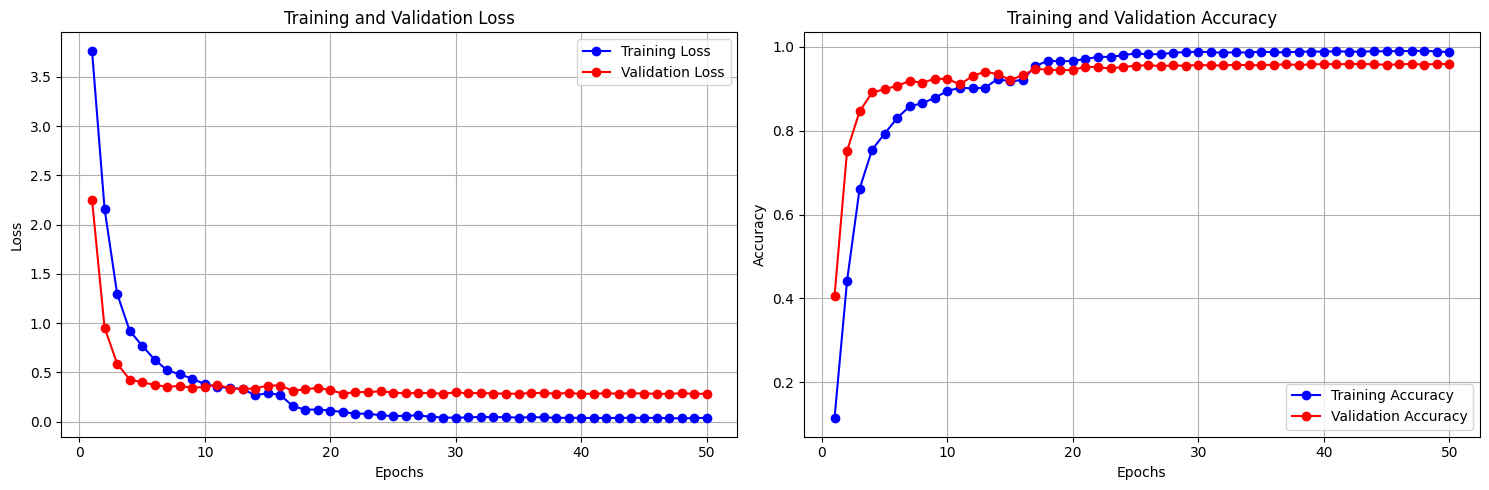

In [24]:
# Plot the history
plot_training_history(
    training_history['train_loss'], 
    training_history['val_loss'], 
    training_history['train_acc'], 
    training_history['val_acc']
)

# Part 6: Evaluation and Analysis

Training and Validation metrics are great for tuning, but the true measure of a model is how it performs on completely unseen data. 
In this section, we will:
1. Load our saved best model.
2. Run it on the Test DataLoader.
3. Generate a Classification Report (Precision, Recall, F1-Score).
4. Plot a Confusion Matrix to see which celebrities are confusing the model.
5. Visually inspect misclassified images to understand *why* the model is failing.

In [25]:
# 1. Re-instantiate the model architecture (EfficientNet-B0)
# Make sure to use the exact same architecture we trained
best_model = create_efficientnet_model(num_classes=num_classes, fine_tune=False)

# 2. Define the path to our saved best model
best_model_path = os.path.join(Config.MODEL_SAVE_PATH, 'best_model.pth')

# 3. Load the weights
print(f"Loading best model weights from: {best_model_path}")
checkpoint = torch.load(best_model_path, map_location=Config.DEVICE)

# Note: Our save_checkpoint function saved a dictionary containing 'state_dict'
best_model.load_state_dict(checkpoint['state_dict'])

# 4. Move to GPU and set to evaluation mode
best_model = best_model.to(Config.DEVICE)
best_model.eval() # 🛑 CRITICAL: Turns off dropout and freezes batch normalization

print(f"Model loaded successfully. Best Validation Accuracy was: {checkpoint['best_acc']:.4f}")

Loading best model weights from: ./saved_models\best_model.pth
Model loaded successfully. Best Validation Accuracy was: 0.9594


## 6.1 Performance on the Test Set

We will now iterate through the `test_loader` and collect all the predictions. We use `torch.no_grad()` to tell PyTorch not to track history, which saves a massive amount of memory and speeds up inference.

In [26]:
# Lists to store true labels and predicted labels
all_preds = []
all_labels = []

print("Running inference on the Test Set...")

with torch.no_grad(): # Disable gradient calculation for inference
    for inputs, labels in tqdm(test_loader, desc="Testing"):
        inputs = inputs.to(Config.DEVICE)
        labels = labels.to(Config.DEVICE)
        
        # Forward pass
        outputs = best_model(inputs)
        
        # Get the index of the max log-probability
        _, preds = torch.max(outputs, 1)
        
        # Move tensors to CPU and convert to numpy lists
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Convert numerical indices back to celebrity names for readability
pred_names = [idx_to_class[idx] for idx in all_preds]
true_names = [idx_to_class[idx] for idx in all_labels]

# Print the Classification Report
print("\n--- Classification Report ---")
# We use zero_division=0 to suppress warnings if a class has 0 predictions
report = classification_report(true_names, pred_names, zero_division=0)
print(report)

# Calculate overall accuracy manually as a sanity check
test_accuracy = np.sum(np.array(all_preds) == np.array(all_labels)) / len(all_labels)
print(f"\nFinal Test Accuracy: {test_accuracy * 100:.2f}%")

Running inference on the Test Set...


Testing:   0%|          | 0/115 [00:00<?, ?it/s]


--- Classification Report ---
                      precision    recall  f1-score   support

          Aamir_Khan       0.95      0.95      0.95        21
          Abhay_Deol       0.90      0.82      0.86        11
   Abhishek_Bachchan       0.93      0.88      0.90        16
    Aftab_Shivdasani       1.00      1.00      1.00        17
       Aishwarya_Rai       1.00      0.92      0.96        24
          Ajay_Devgn       0.94      1.00      0.97        17
        Akshay_Kumar       0.86      1.00      0.93        19
      Akshaye_Khanna       1.00      1.00      1.00        13
          Alia_Bhatt       0.96      0.92      0.94        25
       Ameesha_Patel       0.90      1.00      0.95        18
    Amitabh_Bachchan       0.91      1.00      0.95        20
          Amrita_Rao       0.94      0.89      0.91        18
         Amy_Jackson       0.95      1.00      0.97        18
         Anil_Kapoor       1.00      0.94      0.97        16
      Anushka_Sharma       0.75      0

## 6.2 The Confusion Matrix

With ~100 classes, a standard text-based classification report is hard to digest. A confusion matrix heatmap allows us to visualize where the model is making mistakes. Strong values on the diagonal mean correct predictions. Light spots off the diagonal indicate common mix-ups (e.g., confusing "Yami Gautam" with "Alia Bhatt").

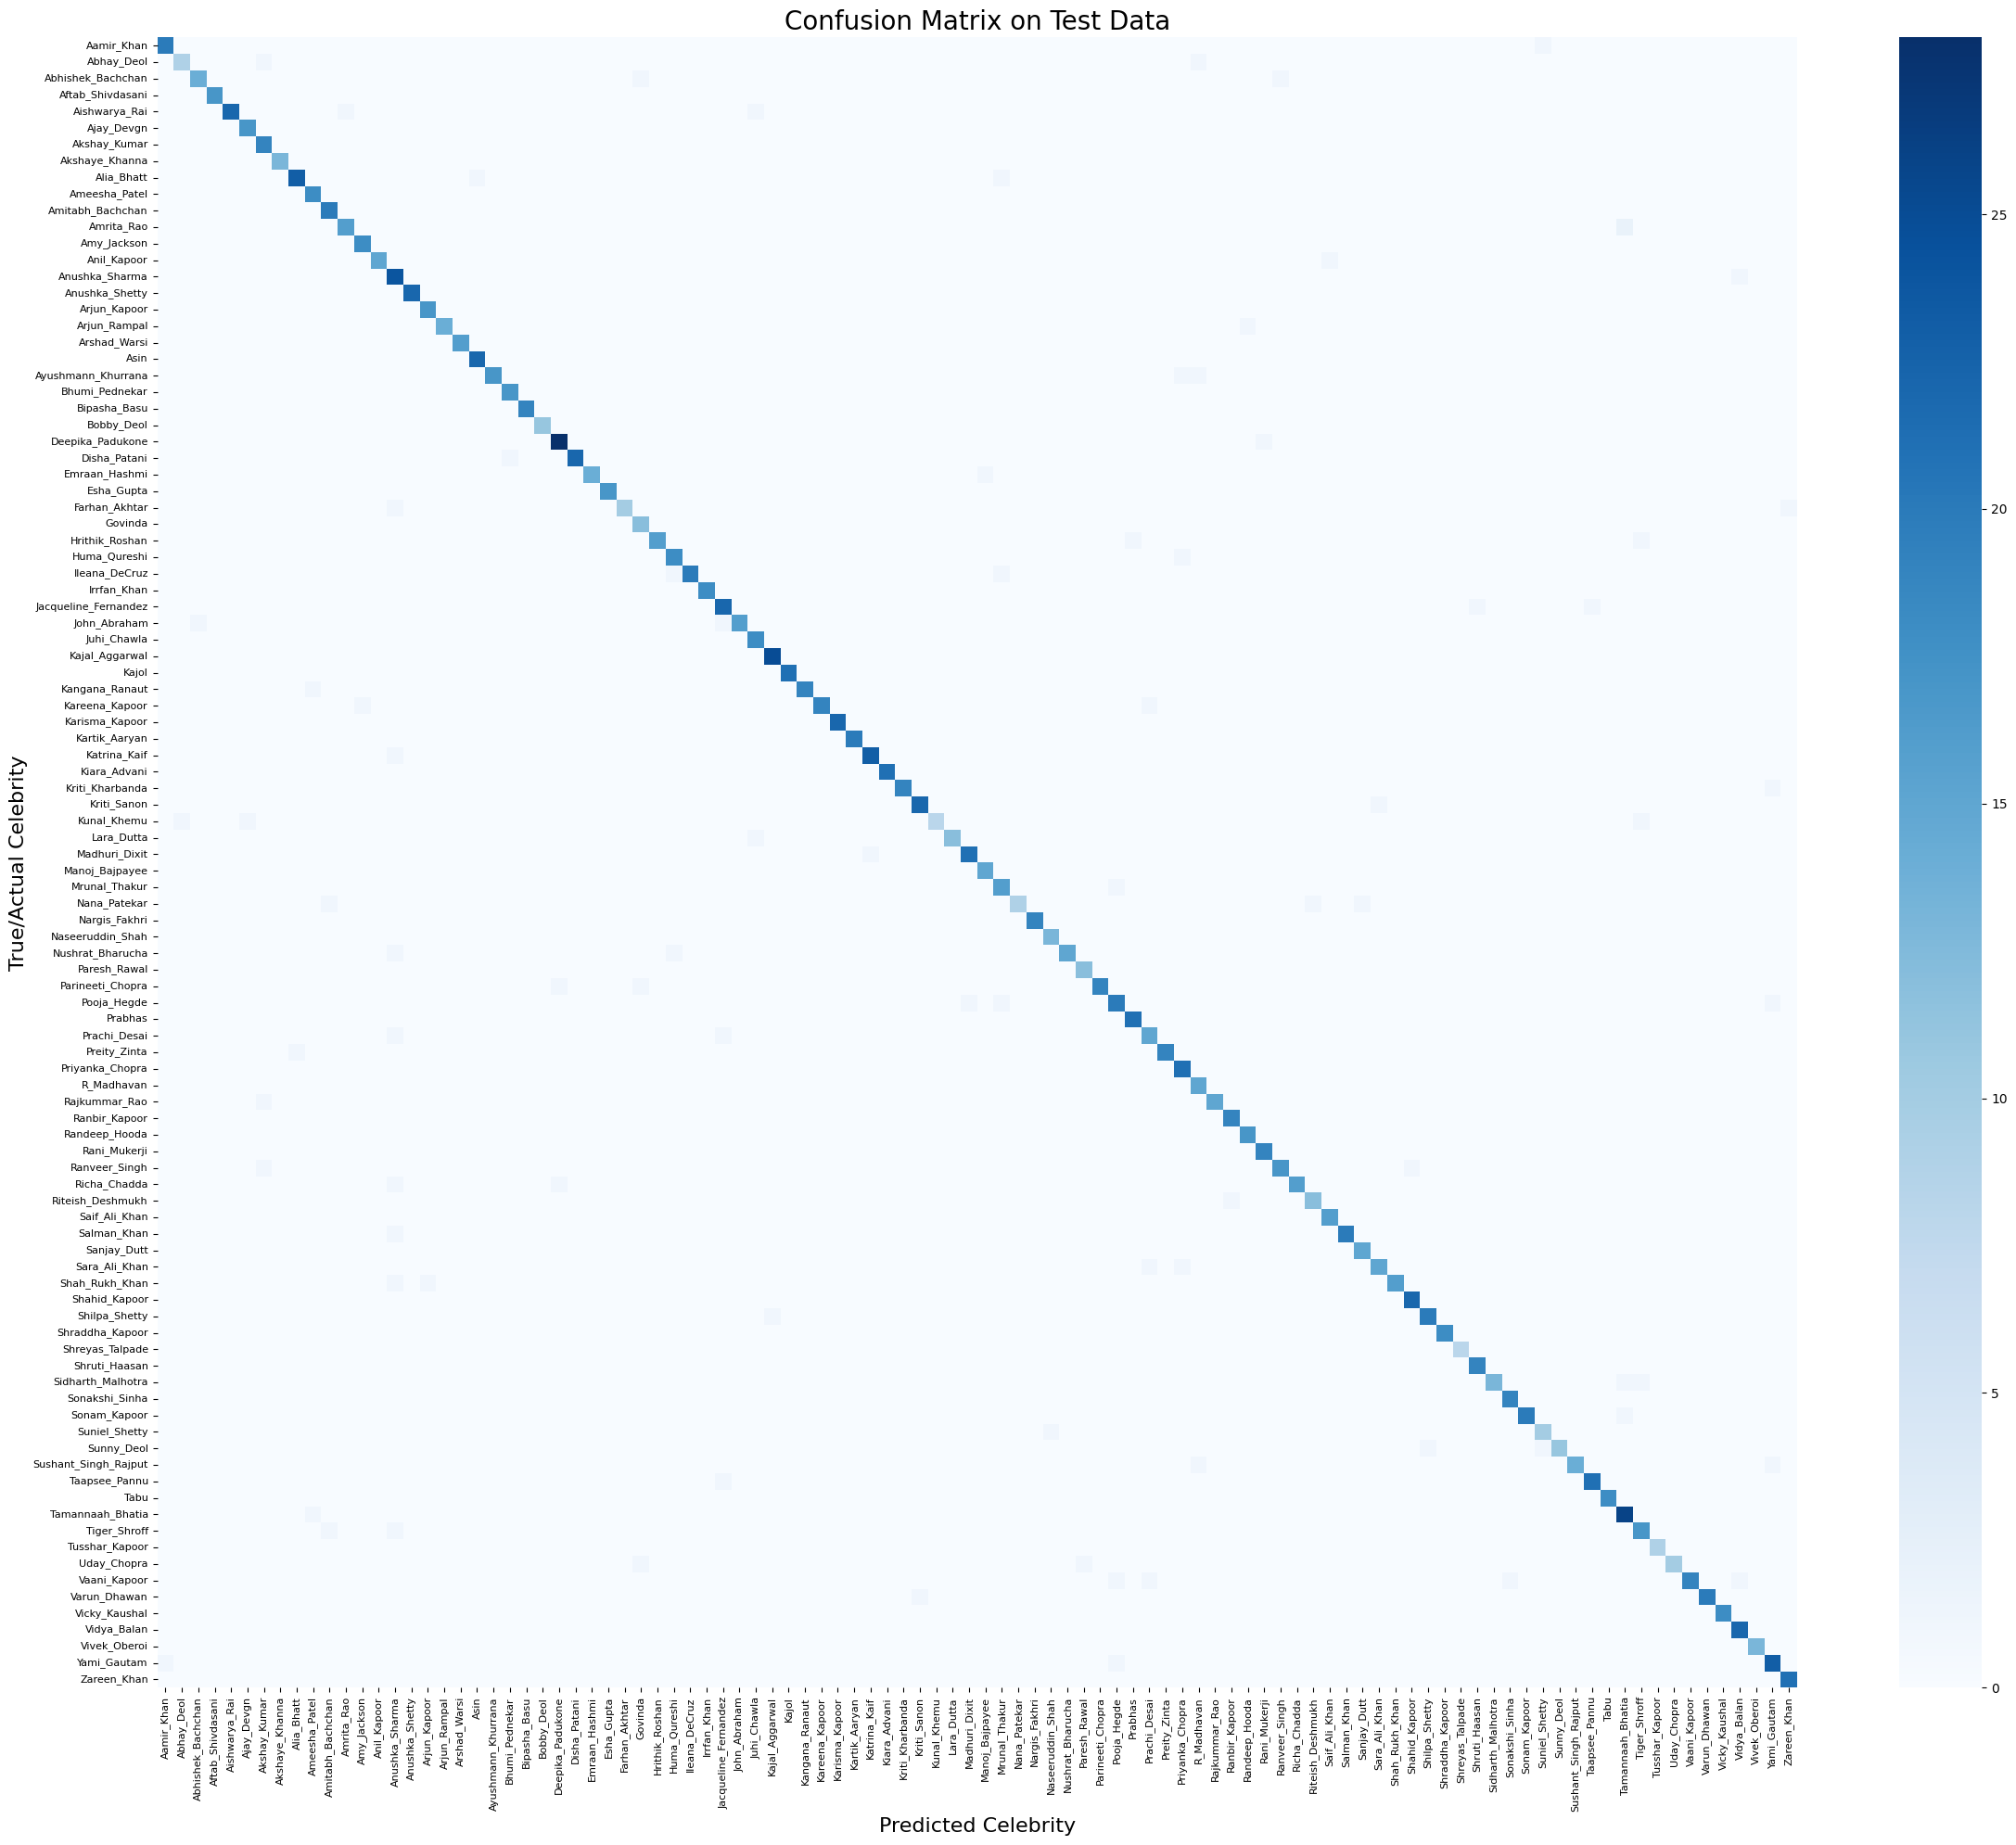

In [27]:
# Generate the confusion matrix
cm = confusion_matrix(true_names, pred_names, labels=unique_classes)

# Since we have many classes, we need a large figure
plt.figure(figsize=(24, 20))

# Plot the heatmap
# annot=False because 100x100 numbers will be unreadable. We rely on color.
sns.heatmap(cm, xticklabels=unique_classes, yticklabels=unique_classes, 
            cmap='Blues', annot=False, cbar=True)

plt.title('Confusion Matrix on Test Data', fontsize=20)
plt.xlabel('Predicted Celebrity', fontsize=16)
plt.ylabel('True/Actual Celebrity', fontsize=16)

# Rotate x-labels for better readability
plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)

plt.tight_layout()
plt.show()

## 6.3 Qualitative Error Analysis (Visualizing Misclassifications)

Metrics tell us *how much* the model is failing. Visualizing the errors tells us *why*. 
Are the misclassified faces blurry? Are they profile shots? Are they actors who genuinely look very similar? Let's plot some of the errors.

Total misclassified images in test set: 88


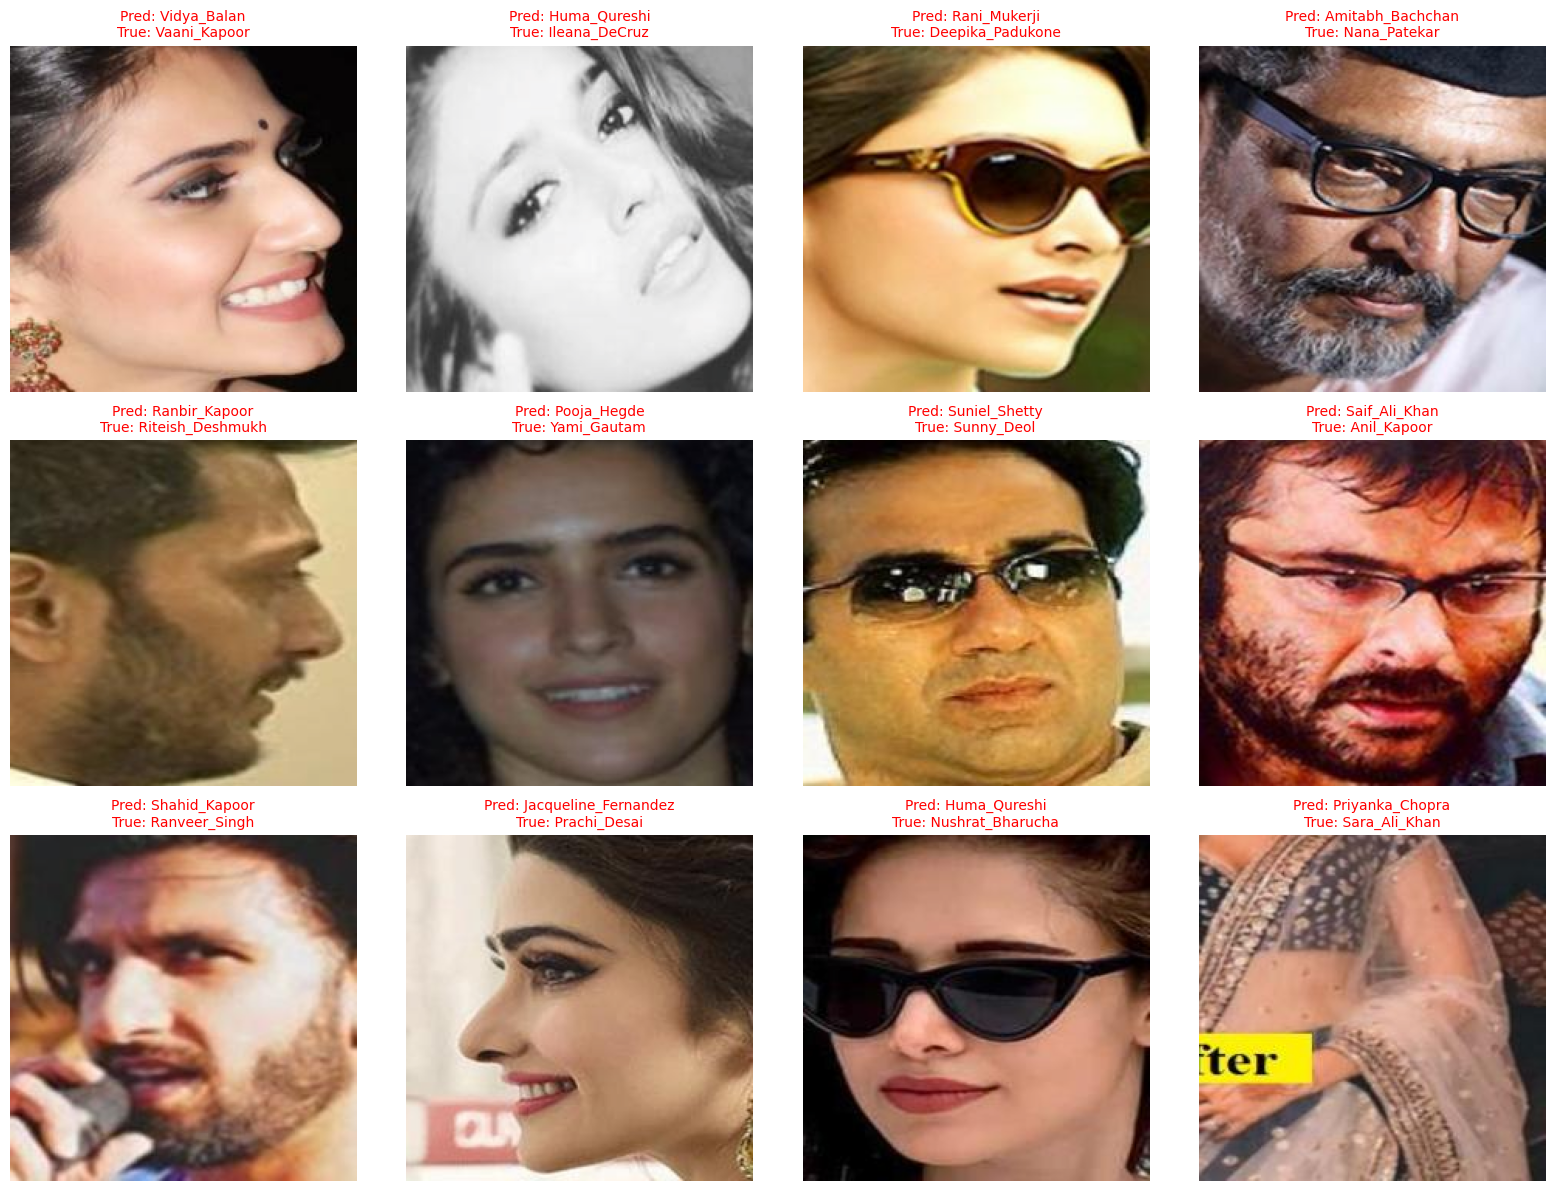

In [28]:
# Find indices where prediction does not match the true label
misclassified_indices = np.where(np.array(all_preds) != np.array(all_labels))[0]

print(f"Total misclassified images in test set: {len(misclassified_indices)}")

if len(misclassified_indices) > 0:
    plt.figure(figsize=(16, 12))
    
    # We will plot up to 12 misclassified images
    num_to_plot = min(12, len(misclassified_indices))
    
    # Randomly select from the misclassified indices to get a varied look
    np.random.seed(Config.RANDOM_SEED)
    sample_indices = np.random.choice(misclassified_indices, num_to_plot, replace=False)
    
    for i, idx in enumerate(sample_indices):
        plt.subplot(3, 4, i + 1)
        
        # We need to get the image tensor from the test_dataset
        # The dataset returns (image_tensor, label)
        img_tensor, true_label_idx = test_dataset[idx]
        
        # Get the predicted label for this index
        pred_label_idx = all_preds[idx]
        
        # Get string names
        true_name = idx_to_class[true_label_idx.item()] # .item() extracts python number from 0-dim tensor
        pred_name = idx_to_class[pred_label_idx]
        
        # Use our utility function to display the tensor
        imshow_tensor(img_tensor, normalize=True)
        
        # Add labels. Red for prediction, Green for true.
        plt.title(f"Pred: {pred_name}\nTrue: {true_name}", color='red', fontsize=10)
        
    plt.tight_layout()
    plt.show()
else:
    print("Incredible! The model got 100% accuracy on the test set. No misclassifications to show.")

## Automated Hyperparameter Tuning (Using Optuna)

Instead of manually guessing hyperparameters, we can use **Optuna** to find the optimal combination. 
Optuna runs multiple "trials." In each trial, it picks a new set of hyperparameters, trains a model for a few epochs, and checks the validation accuracy. It learns from past trials to guess better parameters for the next trial.

*Note: We will train for only 3 epochs per trial to save time. In a real-world scenario, you might run this overnight with 10+ epochs per trial.*

In [ ]:
# Uncomment and run if you don't have Optuna installed
# !pip install optuna

import optuna
import torch.optim as optim

print(f"Optuna version: {optuna.__version__}")

In [ ]:
print("Starting Optuna Hyperparameter Search...")

# We want to MAXIMIZE validation accuracy
study = optuna.create_study(direction="maximize")

# Run 10 different combinations (trials)
# Warning: This might take 10-20 minutes depending on your GPU!
study.optimize(objective, n_trials=10)

print("\n--- Hyperparameter Search Complete ---")
print(f"Number of finished trials: {len(study.trials)}")
print(f"Best trial achieved Validation Accuracy: {study.best_trial.value:.4f}")

print("\nBest Hyperparameters found:")
for key, value in study.best_trial.params.items():
    print(f"    {key}: {value}")